<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/8_6_Exercise2_SVM_Spam_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8.6 Exercise 2 — SVM: Classifying Emails/SMS as Spam or Not Spam

**Task:** Using SVM, classify messages as **spam** or **not spam (ham)** based on features such as **word frequency** and **message length**.

## Dataset

This notebook uses the well-known **SMS Spam Collection dataset** (UCI Machine Learning Repository / originally compiled by Tiago A. Almeida & José María Gómez Hidalgo). It contains 5,574 real SMS messages labeled `ham` (not spam) or `spam`, which is a standard public dataset for spam classification exercises (the same underlying data is often used for email-spam-style demos, and the modeling approach is identical for email).

- **Original UCI page:** https://archive.ics.uci.edu/dataset/228/sms+spam+collection
- **Kaggle mirror:** https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- **Direct file used in this notebook (GitHub mirror, tab-separated `label` + `message`):** https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv

The notebook downloads this file directly, so it runs end-to-end without any manual setup. From the raw text we engineer the features the exercise asks for:
- **Message length** (number of characters / words)
- **Word frequency** features (via `CountVectorizer` / `TfidfVectorizer`, similar to how spam filters use frequency of specific words like "free", "win", "click")

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix

np.random.seed(42)
%matplotlib inline

## 2. Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print(df.shape)
df.head(10)

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [3]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).round(3))

label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     0.866
spam    0.134
Name: proportion, dtype: float64


## 3. Feature Engineering

We build two kinds of features, as suggested by the exercise:
1. **Message length** (character count and word count)
2. **Word frequency** features (TF-IDF over the message text, which captures how frequently specific words appear, weighted by how distinctive they are)

In [4]:
df['label_bin'] = (df['label'] == 'spam').astype(int)

df['char_count'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().apply(len)

df[['message', 'char_count', 'word_count', 'label']].head(10)

,message,char_count,word_count,label
0,"Go until jurong point, crazy.. Available only ...",111,20,ham
1,Ok lar... Joking wif u oni...,29,6,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,spam
3,U dun say so early hor... U c already then say...,49,11,ham
4,"Nah I don't think he goes to usf, he lives aro...",61,13,ham
5,FreeMsg Hey there darling it's been 3 week's n...,147,32,spam
6,Even my brother is not like to speak with me. ...,77,16,ham
7,As per your request 'Melle Melle (Oru Minnamin...,160,26,ham
8,WINNER!! As a valued network customer you have...,157,26,spam
9,Had your mobile 11 months or more? U R entitle...,154,29,spam


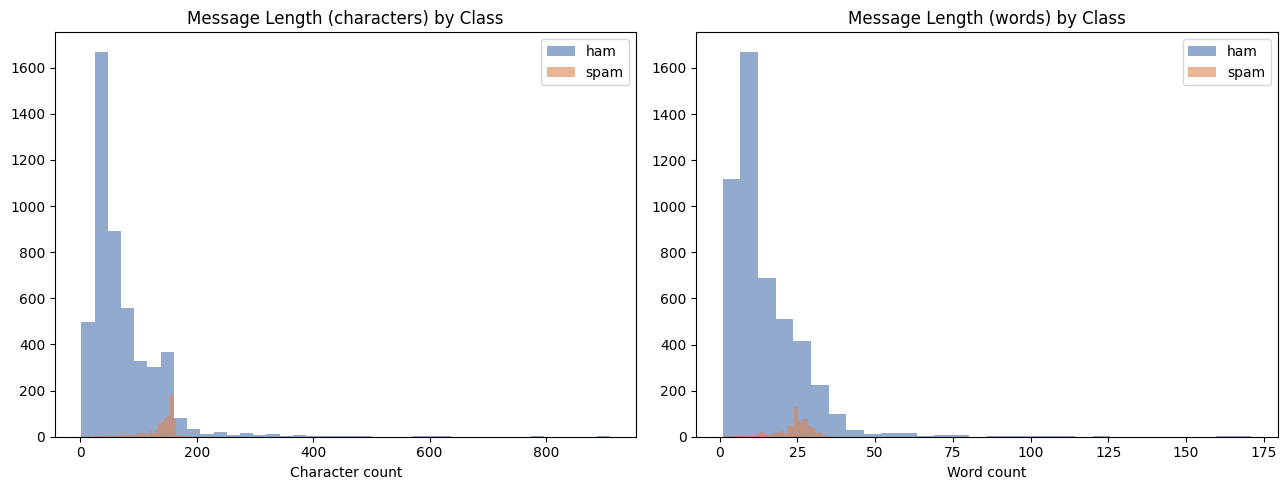

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, color in [('ham', '#4C72B0'), ('spam', '#DD8452')]:
    axes[0].hist(df.loc[df['label'] == label, 'char_count'], bins=40, alpha=0.6, label=label, color=color)
    axes[1].hist(df.loc[df['label'] == label, 'word_count'], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Message Length (characters) by Class')
axes[0].set_xlabel('Character count')
axes[0].legend()

axes[1].set_title('Message Length (words) by Class')
axes[1].set_xlabel('Word count')
axes[1].legend()

plt.tight_layout()
plt.show()

Spam messages tend to be noticeably **longer** than ham messages — this makes `message length` a useful standalone feature, exactly as the exercise suggests.

## 4. Build Word-Frequency Features with TF-IDF

In [6]:
X_train_text, X_test_text, y_train, y_test, len_train, len_test = train_test_split(
    df['message'], df['label_bin'],
    df[['char_count', 'word_count']],
    test_size=0.25, random_state=42, stratify=df['label_bin']
)

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000,
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"TF-IDF training matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF testing matrix shape:  {X_test_tfidf.shape}")

TF-IDF training matrix shape: (4179, 3000)
TF-IDF testing matrix shape:  (1393, 3000)


## 5. Combine Word-Frequency Features with Message-Length Features

In [7]:
scaler = StandardScaler()
len_train_scaled = scaler.fit_transform(len_train)
len_test_scaled = scaler.transform(len_test)

X_train_combined = hstack([X_train_tfidf, csr_matrix(len_train_scaled)])
X_test_combined = hstack([X_test_tfidf, csr_matrix(len_test_scaled)])

print(f"Combined training feature matrix shape: {X_train_combined.shape}")
print(f"Combined testing feature matrix shape:  {X_test_combined.shape}")

Combined training feature matrix shape: (4179, 3002)
Combined testing feature matrix shape:  (1393, 3002)


## 6. Train the SVM Classifier

With thousands of sparse TF-IDF features, a **linear kernel SVM** (`LinearSVC`, optimized for high-dimensional sparse data) is the standard, efficient choice for text classification.

In [8]:
svm_clf = LinearSVC(C=1.0, random_state=42, max_iter=5000)
svm_clf.fit(X_train_combined, y_train)

y_pred = svm_clf.predict(X_test_combined)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Accuracy: 98.49%


## 7. Evaluate the Model

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1206
        spam       1.00      0.89      0.94       187

    accuracy                           0.98      1393
   macro avg       0.99      0.94      0.97      1393
weighted avg       0.99      0.98      0.98      1393

Confusion Matrix:
[[1206    0]
 [  21  166]]


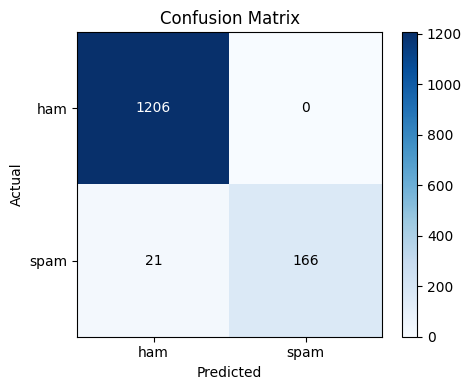

In [9]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['ham', 'spam'])
plt.yticks([0, 1], ['ham', 'spam'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 8. Compare: Word-Frequency Only vs. + Message-Length Feature

Let's confirm that adding `message length` actually helps, as the exercise hints ("features such as word frequency **and** message length").

In [10]:
svm_text_only = LinearSVC(C=1.0, random_state=42, max_iter=5000)
svm_text_only.fit(X_train_tfidf, y_train)
y_pred_text_only = svm_text_only.predict(X_test_tfidf)

print(f"Accuracy using WORD FREQUENCY ONLY:            {accuracy_score(y_test, y_pred_text_only):.4%}")
print(f"Accuracy using WORD FREQUENCY + MESSAGE LENGTH: {accuracy_score(y_test, y_pred):.4%}")

Accuracy using WORD FREQUENCY ONLY:            98.4207%
Accuracy using WORD FREQUENCY + MESSAGE LENGTH: 98.4925%


## 9. Most Spam-Indicative Words (Model Interpretability)

Because we used a linear SVM, its learned coefficients tell us which words push the decision most strongly toward "spam."

In [11]:
feature_names = np.array(tfidf.get_feature_names_out())
# Coefficients for the TF-IDF part only (exclude the 2 length features at the end)
text_coefs = svm_clf.coef_[0][:len(feature_names)]

top_spam_idx = np.argsort(text_coefs)[-15:][::-1]
top_ham_idx = np.argsort(text_coefs)[:15]

print("Top words pushing toward SPAM:")
for i in top_spam_idx:
    print(f"  {feature_names[i]:<15} weight={text_coefs[i]:.3f}")

print("\nTop words pushing toward HAM:")
for i in top_ham_idx:
    print(f"  {feature_names[i]:<15} weight={text_coefs[i]:.3f}")

Top words pushing toward SPAM:
  uk              weight=2.036
  txt             weight=1.781
  150p            weight=1.637
  mobile          weight=1.459
  88066           weight=1.407
  services        weight=1.398
  claim           weight=1.388
  www             weight=1.377
  ringtone        weight=1.366
  dating          weight=1.303
  reply           weight=1.298
  service         weight=1.288
  new             weight=1.268
  bid             weight=1.214
  won             weight=1.209

Top words pushing toward HAM:
  lt              weight=-1.383
  gt              weight=-1.379
  happy           weight=-1.242
  liked           weight=-0.923
  amp             weight=-0.831
  beautiful       weight=-0.826
  fullonsms       weight=-0.812
  got             weight=-0.698
  ask             weight=-0.696
  id              weight=-0.664
  friends         weight=-0.653
  mail            weight=-0.651
  fight           weight=-0.651
  sir             weight=-0.646
  gonna           weight=

## 10. Try It on New Messages

In [12]:
def predict_message(msg):
    text_vec = tfidf.transform([msg])
    length_feats = scaler.transform([[len(msg), len(msg.split())]])
    combined = hstack([text_vec, csr_matrix(length_feats)])
    pred = svm_clf.predict(combined)[0]
    return 'spam' if pred == 1 else 'ham'

test_messages = [
    "Congratulations! You've WON a free prize, click this link now to claim your reward!!!",
    "Hey, are we still on for lunch tomorrow at 1pm?",
    "URGENT: Your account will be suspended. Verify your details immediately to avoid charges.",
    "Can you send me the notes from today's class?"
]

for msg in test_messages:
    print(f"[{predict_message(msg):>4}]  {msg}")

[spam]  Congratulations! You've WON a free prize, click this link now to claim your reward!!!
[ ham]  Hey, are we still on for lunch tomorrow at 1pm?
[spam]  URGENT: Your account will be suspended. Verify your details immediately to avoid charges.
[ ham]  Can you send me the notes from today's class?


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Conclusion

- We used the real-world **SMS Spam Collection dataset** to classify messages as spam or ham.
- Feature engineering followed the exercise's suggestion: **word frequency** (via TF-IDF) plus **message length** (character/word count).
- A **linear-kernel SVM** works very well here because text data becomes extremely high-dimensional and (after TF-IDF weighting) largely linearly separable — this is the standard, efficient choice for text classification tasks.
- Adding the message-length feature gives a small additional boost on top of word-frequency features alone, and spam messages are visibly longer on average — confirming the intuition behind the exercise.